In [28]:
import numpy as np
import pandas as pd
from matplotlib.lines import lineStyles
from plotly.io import show
from matplotlib import pyplot as plt
import seaborn as sns
from tabulate import tabulate
import vectorbt as vbt
import math

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Utils import *

In [29]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    # "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    # "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    # "TON",  # 20 Toncoin
    # "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    # "MNT",  # 23 Mantle
    # "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Setup

In [30]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC", "ETH", "XRP"]
symbols = top_kraken[:5]
interval = "4h"
n_trials = 50
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.02,
                  'sar_maximum': 0.2,
                  'atr_multiplier': 3,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,  # atr multiplier for chandelier exit
                  'use_high': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)


## Part 1: Initial Parameter Search

In [31]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 0, 80, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, 50, step=2)
    params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
    params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, 50, step=2)
    params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)
trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 19:47:07,790] A new study created in memory with name: no-name-bd3e25ac-0fd1-49c0-afc8-5bb551565011
[I 2025-11-09 19:47:08,738] Trial 0 finished with value: 0.18315758875223526 and parameters: {'adx_threshold': 30, 'adx_length': 48, 'sar_acceleration': 1.11, 'sar_maximum': 1.04, 'atr_multiplier': 2.0, 'atr_length': 16, 'use_high': False}. Best is trial 0 with value: 0.18315758875223526.
[I 2025-11-09 19:47:09,609] Trial 1 finished with value: 0.3309119638861869 and parameters: {'adx_threshold': 48, 'adx_length': 36, 'sar_acceleration': 0.05, 'sar_maximum': 1.6600000000000001, 'atr_multiplier': 7.0, 'atr_length': 18, 'use_high': False}. Best is trial 1 with value: 0.3309119638861869.
[I 2025-11-09 19:47:10,230] Trial 2 finished with value: 0.5921232941429055 and parameters: {'adx_threshold': 24, 'adx_length': 28, 'sar_acceleration': 0.66, 'sar_maximum': 0.53, 'atr_multiplier': 5.5, 'atr_length': 14, 'use_high': False}. Best is trial 2 with value: 0.5921232941429055.
[I 202

Study Results

In [32]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |       value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |   sar_acceleration |   sar_maximum | use_high   |
|----------|-------------|--------------|-----------------|--------------|------------------|--------------------|---------------|------------|
|       18 |   1.46067   |            2 |              22 |           20 |              1   |               0.92 |          0.88 | True       |
|       47 |   1.44768   |            2 |              68 |           38 |              1.5 |               1.23 |          0.51 | False      |
|       46 |   1.44547   |            4 |              16 |           38 |              1.5 |               0.17 |          0.08 | False      |
|        7 |   1.26208   |           10 |               6 |           20 |              3.5 |               0.08 |          0.59 | True       |
|       28 |   1.1901    |           14 |              20 |           36 |              7.5 |               1.46 |          0.7  | True 

In [33]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]','Total Trades']

print(f"\nTop 10% Trials Summary:")
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol Average values:")
print(top_runs.groupby('symbol')[cols].mean())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())


Top 10% Trials Summary:

Per symbol Average values:
        sar_acceleration  sar_maximum  atr_multiplier  adx_threshold  \
symbol                                                                 
BTC                0.772        0.552             3.0           26.4   
ETH                0.672        0.436             2.2           28.8   
SOL                0.704        0.640             2.1           44.0   
TRX                0.492        0.434             2.9           26.8   
XRP                0.664        0.650             2.1           29.2   

        adx_length  atr_length  use_high  Sharpe Ratio  Sortino Ratio  \
symbol                                                                  
BTC            6.4        30.4       0.6      1.728657       2.588085   
ETH           10.0        30.4       0.4      1.042801       1.516256   
SOL            5.2        27.6       0.2      1.627483       2.474451   
TRX            9.6        28.0       0.4      1.484371       2.410769   
XRP 

In [34]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sharpe: 1.46 
|------------------|-------|
| adx_threshold    | 22    |
| adx_length       |  2    |
| sar_acceleration |  0.92 |
| sar_maximum      |  0.88 |
| atr_multiplier   |  1    |
| atr_length       | 20    |
| use_high         |  1    |


Visualization

In [35]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

# fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
# show(fig2)


From the slice plot can notice a few things...

- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6



In [36]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

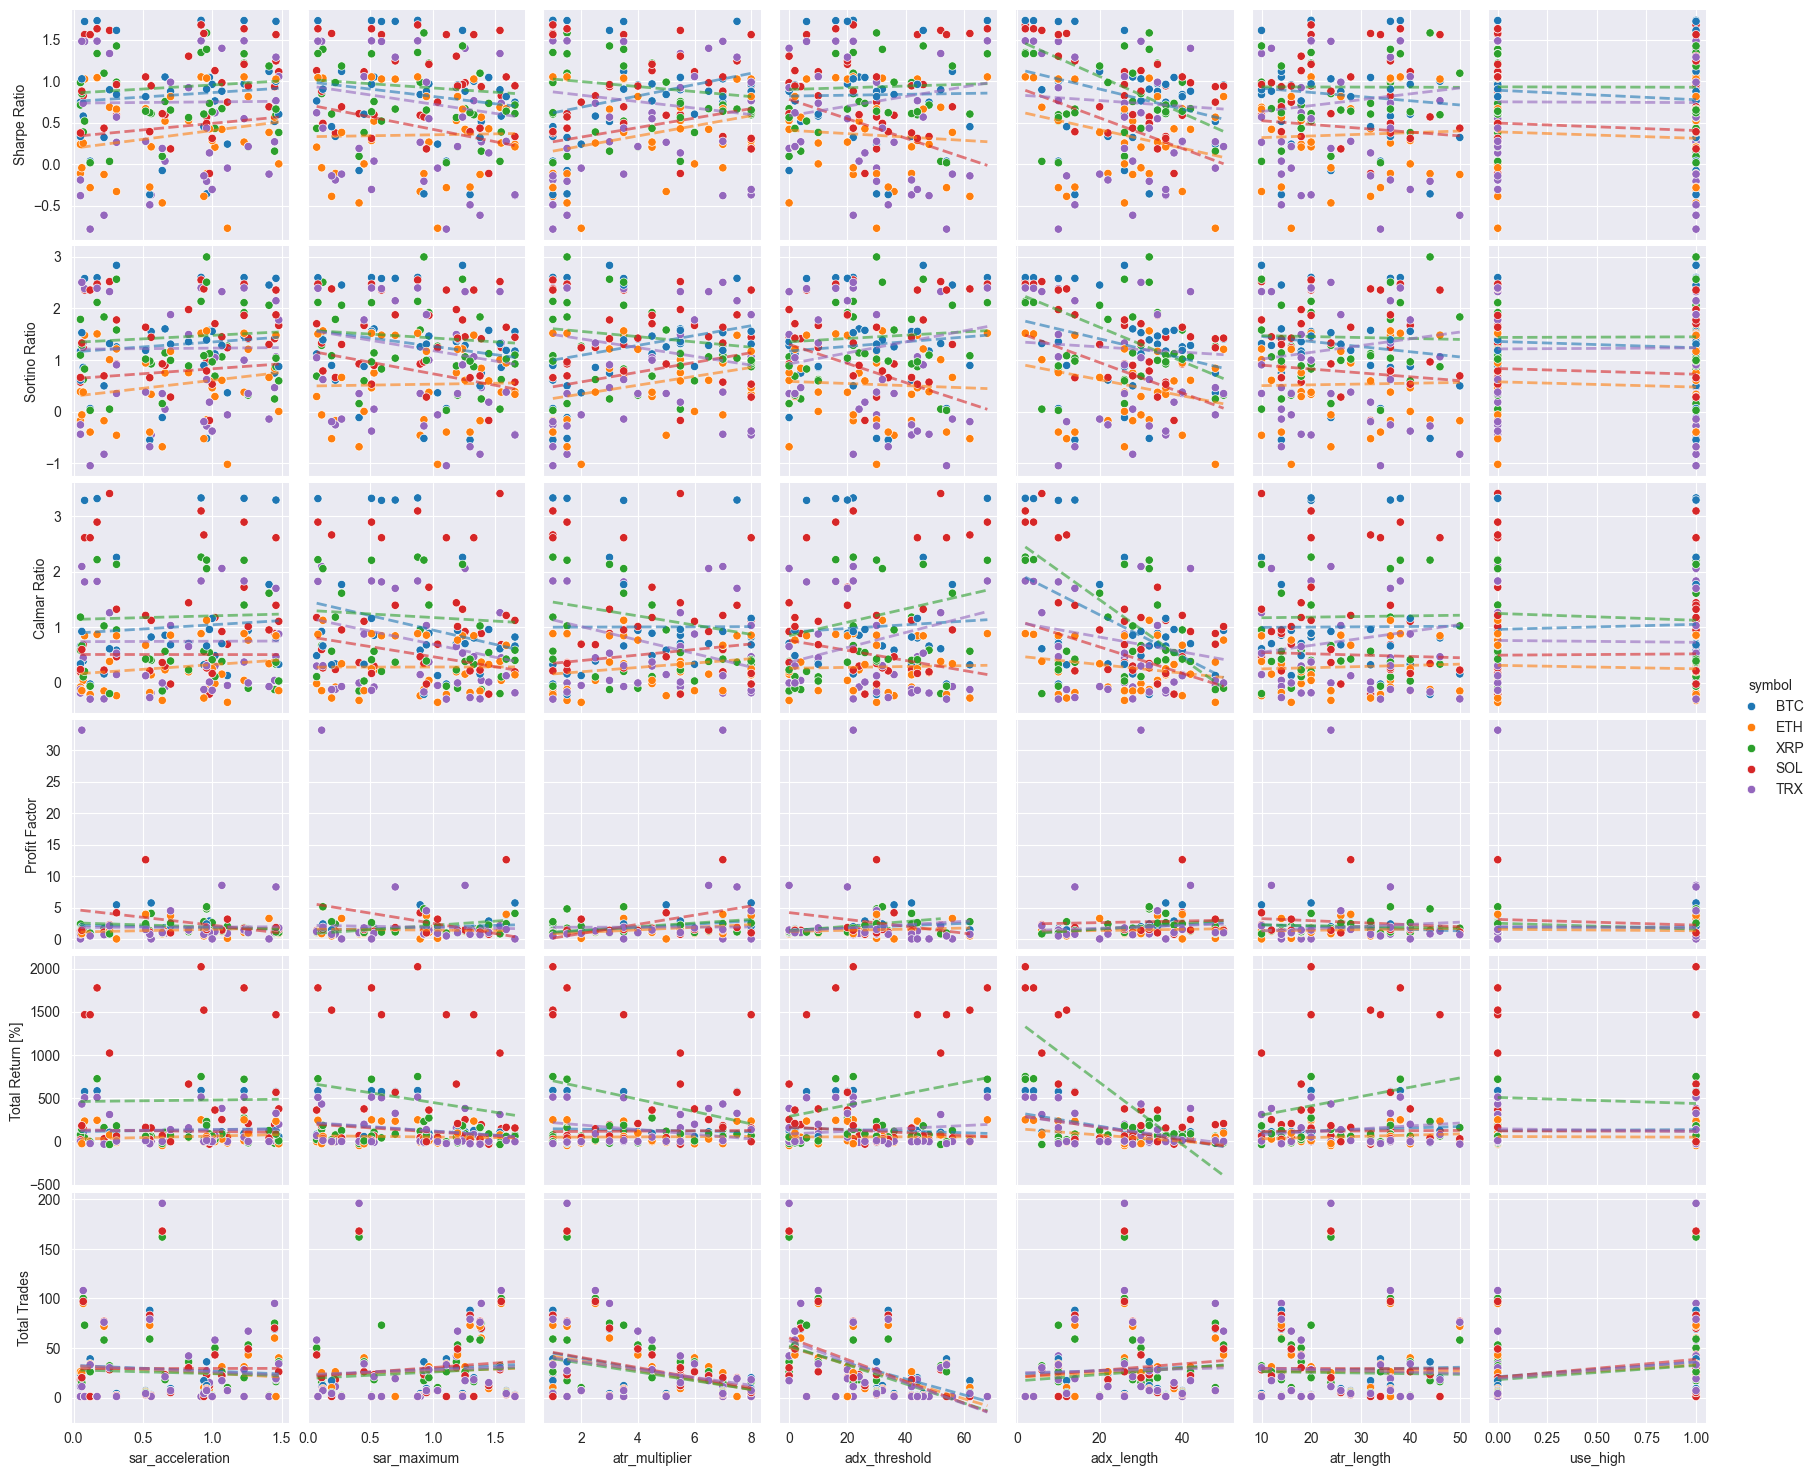

In [37]:

g = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g.axes[i, j]
        for sym, subdf in trials_summary.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




## Part2: Further exploration

Set defaults for values that dont seem to correlate well:
- use_high = False


In [38]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 10, 50, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, 50, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.08, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.07, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 2, 50, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
# reset params
params = params_default.copy()
study2 = optuna.create_study(direction="maximize", sampler=sampler)
study2.optimize(objective, n_trials=n_trials)
trials_summary2 = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 19:47:47,719] A new study created in memory with name: no-name-667c9c11-bafa-406a-b83a-cdffbecaac6a
[I 2025-11-09 19:47:48,339] Trial 0 finished with value: 0.7258649445737468 and parameters: {'adx_threshold': 14, 'adx_length': 46, 'atr_multiplier': 4.5, 'atr_length': 42}. Best is trial 0 with value: 0.7258649445737468.
[I 2025-11-09 19:47:48,942] Trial 1 finished with value: 0.5396082681285996 and parameters: {'adx_threshold': 22, 'adx_length': 46, 'atr_multiplier': 3.5, 'atr_length': 2}. Best is trial 0 with value: 0.7258649445737468.
[I 2025-11-09 19:47:49,869] Trial 2 finished with value: 1.1060845955602356 and parameters: {'adx_threshold': 48, 'adx_length': 6, 'atr_multiplier': 3.0, 'atr_length': 48}. Best is trial 2 with value: 1.1060845955602356.
[I 2025-11-09 19:47:50,489] Trial 3 finished with value: 0.6055166194395547 and parameters: {'adx_threshold': 48, 'adx_length': 30, 'atr_multiplier': 5.5, 'atr_length': 24}. Best is trial 2 with value: 1.1060845955602356.


In [39]:
best_params2 = study2.best_params
best_value2 = study2.best_value
print(f"\nBest --> Sharpe: {best_value2:.2f} ")
print(tabulate(best_params2.items(), tablefmt="github"))


Best --> Sharpe: 1.46 
|----------------|------|
| adx_threshold  | 14   |
| adx_length     |  2   |
| atr_multiplier |  6.5 |
| atr_length     | 32   |


In [40]:
print(f"\nTop 10% Trials Summary:")
parameters = list(best_params2.keys())
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary2.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())


Top 10% Trials Summary:

Per symbol:
       adx_threshold                                                 \
               count  mean        std   min   25%   50%   75%   max   
symbol                                                                
BTC              5.0  26.8  14.463748  14.0  14.0  24.0  34.0  48.0   
ETH              5.0  31.6  12.280065  14.0  24.0  38.0  38.0  44.0   
SOL              5.0  30.8  12.696456  14.0  24.0  34.0  34.0  48.0   
TRX              5.0  20.4   8.648699  14.0  14.0  16.0  24.0  34.0   
XRP              5.0  28.8   9.121403  14.0  26.0  34.0  34.0  36.0   

       adx_length        ... Total Return [%]              Total Trades        \
            count  mean  ...              75%          max        count  mean   
symbol                   ...                                                    
BTC           5.0   5.2  ...       585.633380   589.187875          5.0   1.0   
ETH           5.0  16.0  ...       180.837292   249.838165          5

In [41]:
fig3 = optuna.visualization.plot_param_importances(study2)
show(fig3)

# fig4 = optuna.visualization.plot_slice(study2, params=best_params2.keys())
# show(fig4)


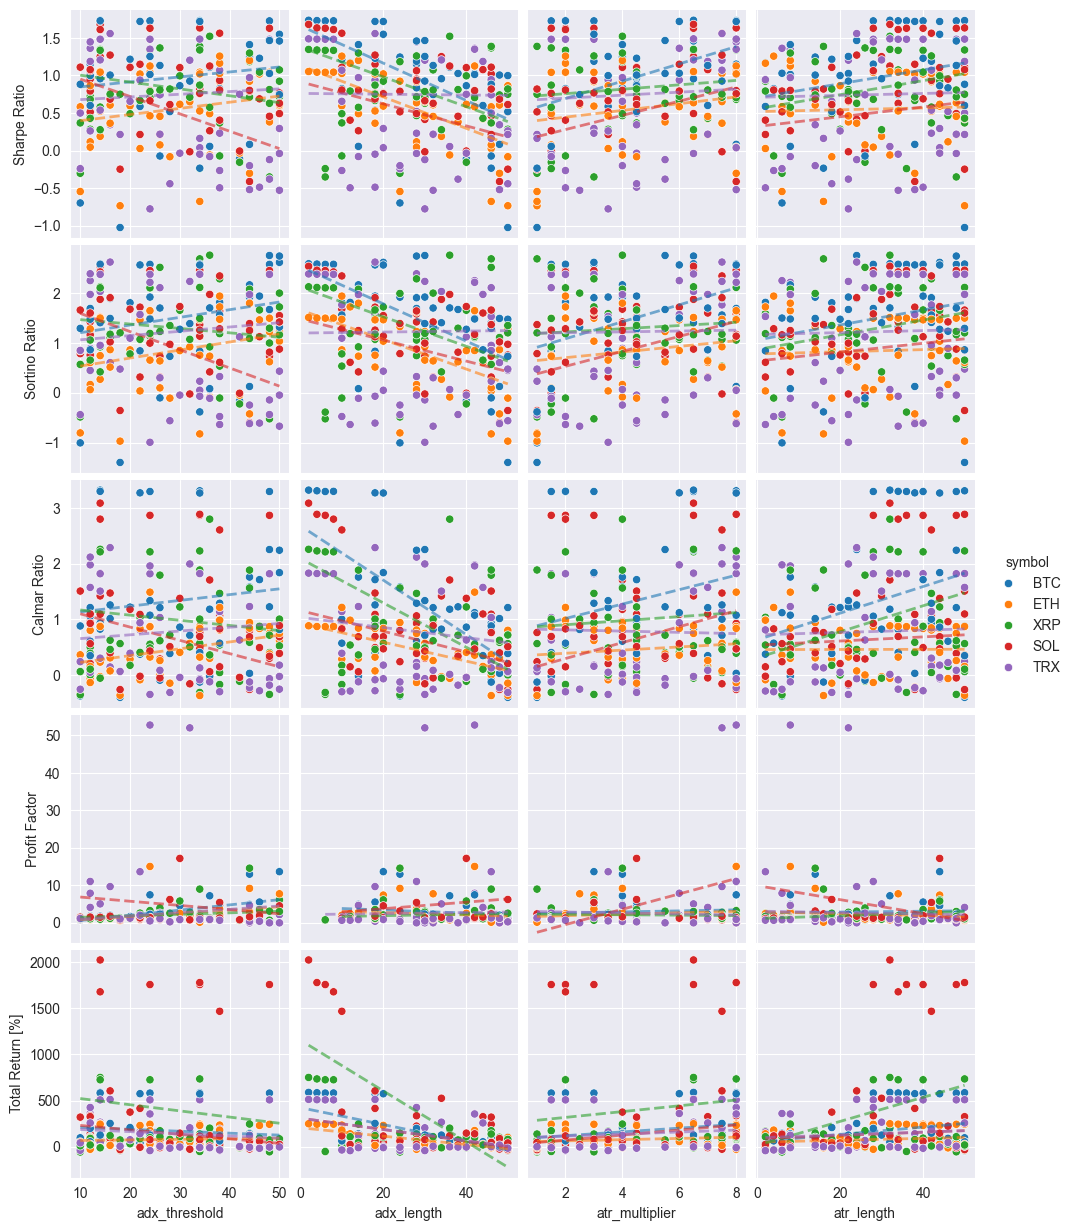

In [42]:
parameters = list(best_params2.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']
g2 = sns.pairplot(
    trials_summary2,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g2.axes[i, j]
        for sym, subdf in trials_summary2.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




### All Symbols

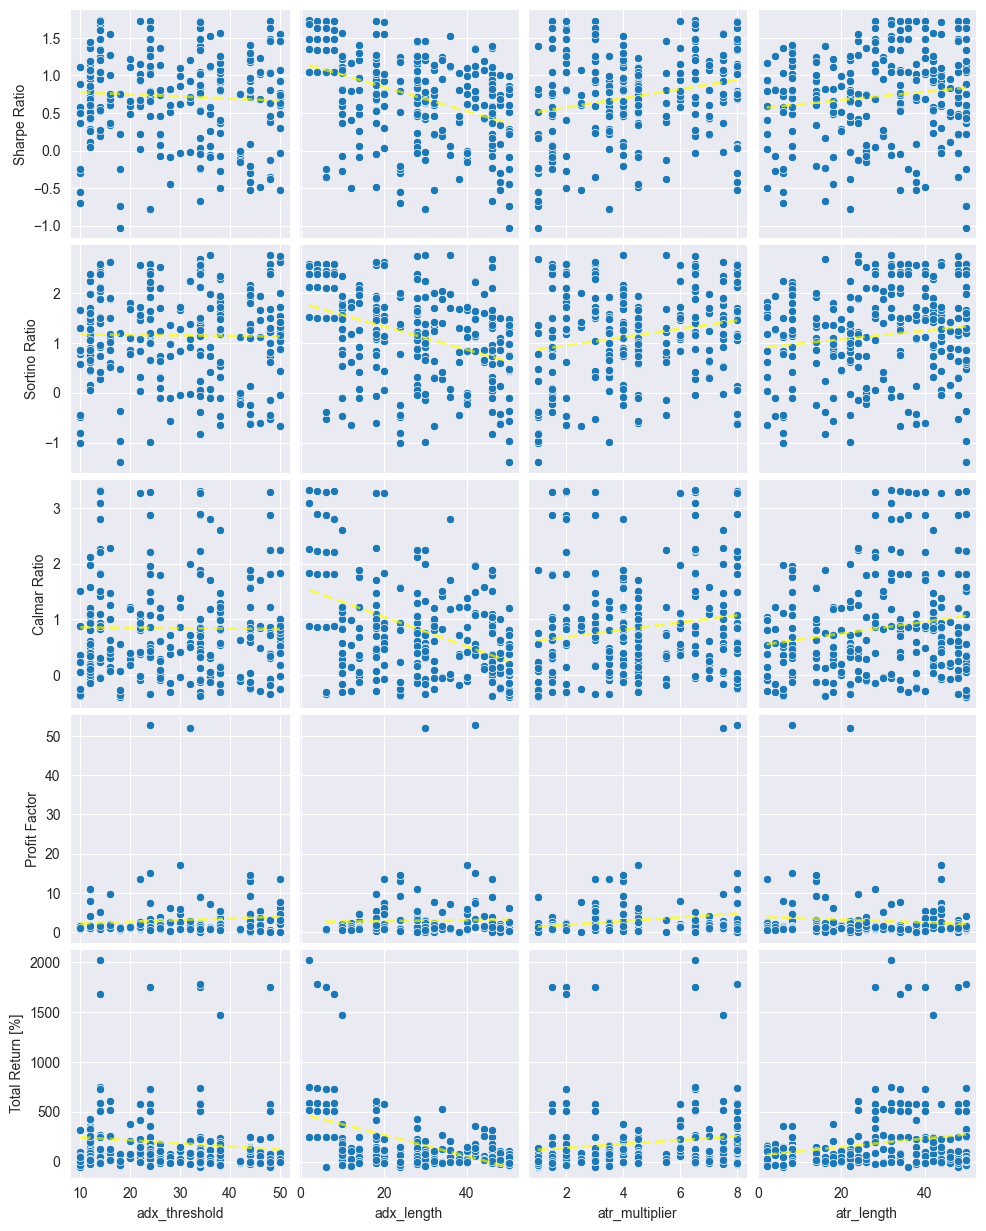

In [43]:
g3 = sns.pairplot(
    trials_summary2,
    x_vars=parameters,
    y_vars=performance,

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g3.axes[i, j]
        sns.regplot(
            data=trials_summary2,
            x=x,
            y=y,
            scatter=False,
            ci=None,
            ax=ax,

            line_kws={
                "linestyle": "--",  # dashed line
                "alpha": 0.6,  # transparency
                "lw": 2,  # line width
                "color": "yellow",
            },
        )


## Part 3: Final Results

In [44]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 25, 45, step=1)  #
    params['adx_length'] = trial.suggest_int("adx_length", 10, 25, step=1)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.08, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.07, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 3, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 14, 40, step=1)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        print(params)
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
# reset params
params = params_default.copy()
study3 = optuna.create_study(direction="maximize", sampler=sampler)
study3.optimize(objective, n_trials=n_trials)
trials_summary3 = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 19:48:25,414] A new study created in memory with name: no-name-af8f19f8-052c-48d9-a76d-4de80e215c49
[I 2025-11-09 19:48:26,375] Trial 0 finished with value: 0.887779980886265 and parameters: {'adx_threshold': 28, 'adx_length': 14, 'atr_multiplier': 3.5, 'atr_length': 16}. Best is trial 0 with value: 0.887779980886265.
[I 2025-11-09 19:48:27,000] Trial 1 finished with value: 0.9383469356192068 and parameters: {'adx_threshold': 27, 'adx_length': 17, 'atr_multiplier': 4.0, 'atr_length': 23}. Best is trial 1 with value: 0.9383469356192068.
[I 2025-11-09 19:48:27,622] Trial 2 finished with value: 0.6986037074632246 and parameters: {'adx_threshold': 35, 'adx_length': 21, 'atr_multiplier': 3.0, 'atr_length': 35}. Best is trial 1 with value: 0.9383469356192068.
[I 2025-11-09 19:48:28,274] Trial 3 finished with value: 0.9333995367479396 and parameters: {'adx_threshold': 38, 'adx_length': 11, 'atr_multiplier': 7.5, 'atr_length': 38}. Best is trial 1 with value: 0.9383469356192068.


In [45]:
best_params3 = study3.best_params
best_value3 = study3.best_value
print(f"\nBest --> Sharpe: {best_value3:.2f} ")
print(tabulate(best_params3.items(), tablefmt="github"))


Best --> Sharpe: 1.21 
|----------------|----|
| adx_threshold  | 27 |
| adx_length     | 16 |
| atr_multiplier |  8 |
| atr_length     | 37 |


In [46]:
print(f"\nTop 10% Trials Summary:")
parameters = list(best_params3.keys())
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary3.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

# nan values?

print(f"\nBot 10% Trials Summary:")
bot_runs = trials_summary3.sort_values('Sharpe Ratio', ascending=True).groupby('symbol').head(top_10_pct)
print(f"\nAcross all symbols:")
print(bot_runs[cols].describe())

# final look

print(trials_summary.info())

# Why are some Profit factor NaN or inf


Top 10% Trials Summary:

Per symbol:
       adx_threshold                                               adx_length  \
               count  mean       std   min   25%   50%   75%   max      count   
symbol                                                                          
BTC              5.0  32.4  7.021396  27.0  28.0  29.0  34.0  44.0        5.0   
ETH              5.0  38.4  3.286335  35.0  35.0  39.0  41.0  42.0        5.0   
SOL              5.0  36.0  6.595453  29.0  30.0  36.0  41.0  44.0        5.0   
TRX              5.0  30.4  5.319774  26.0  27.0  27.0  34.0  38.0        5.0   
XRP              5.0  41.4  3.577709  37.0  38.0  44.0  44.0  44.0        5.0   

              ... Profit Factor            Total Return [%]               \
        mean  ...           75%        max            count         mean   
symbol        ...                                                          
BTC     15.4  ...      7.103262   7.103262              5.0   495.730005   
ETH     1

In [47]:
fig5 = optuna.visualization.plot_param_importances(study3)
show(fig5)


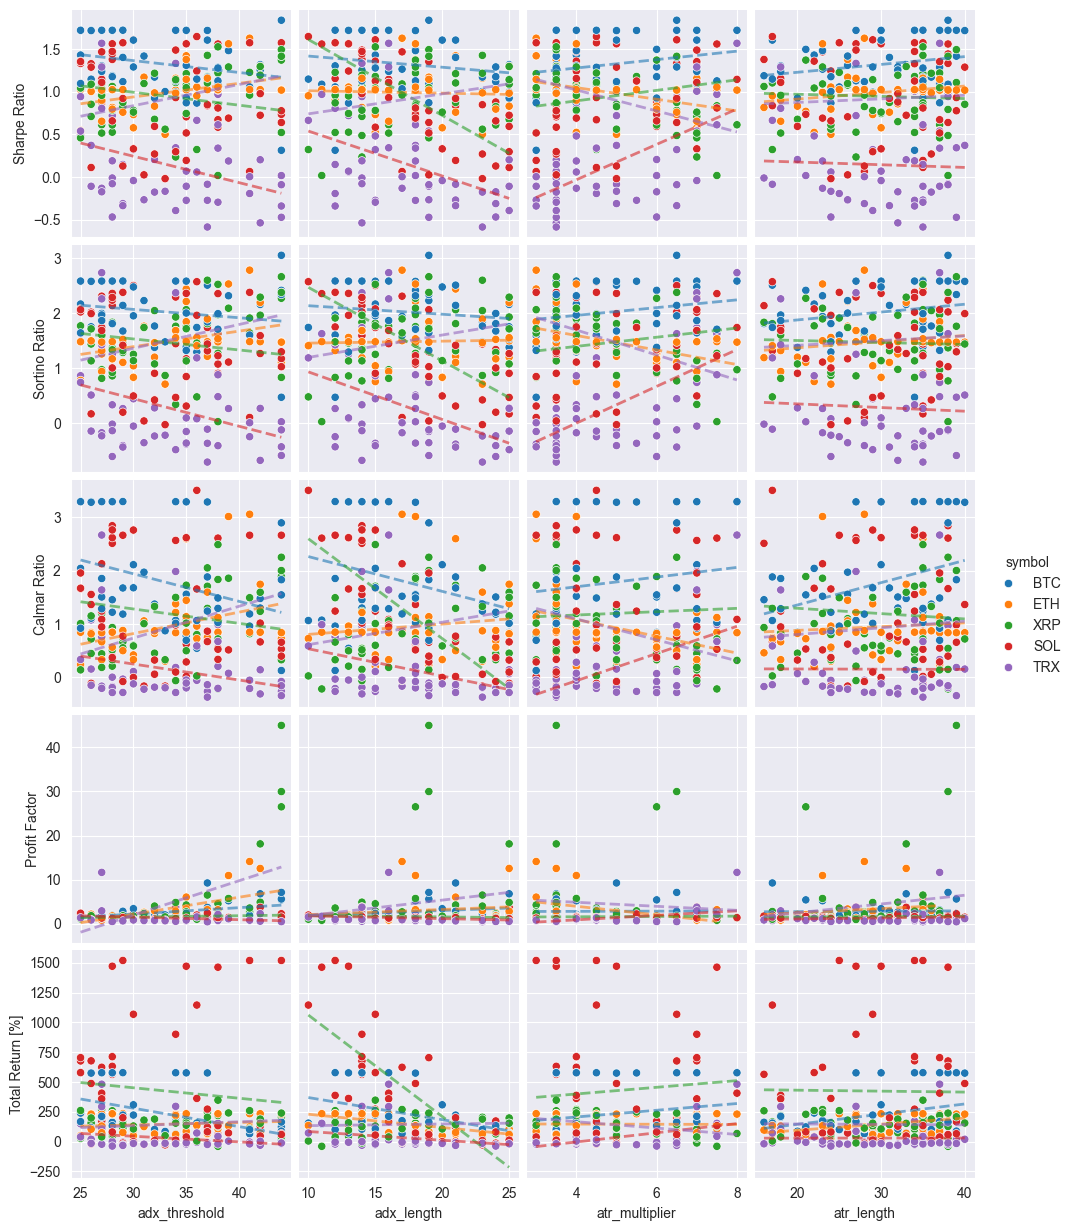

In [48]:
parameters = list(best_params3.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']
g4 = sns.pairplot(
    trials_summary3,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g4.axes[i, j]
        for sym, subdf in trials_summary3.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




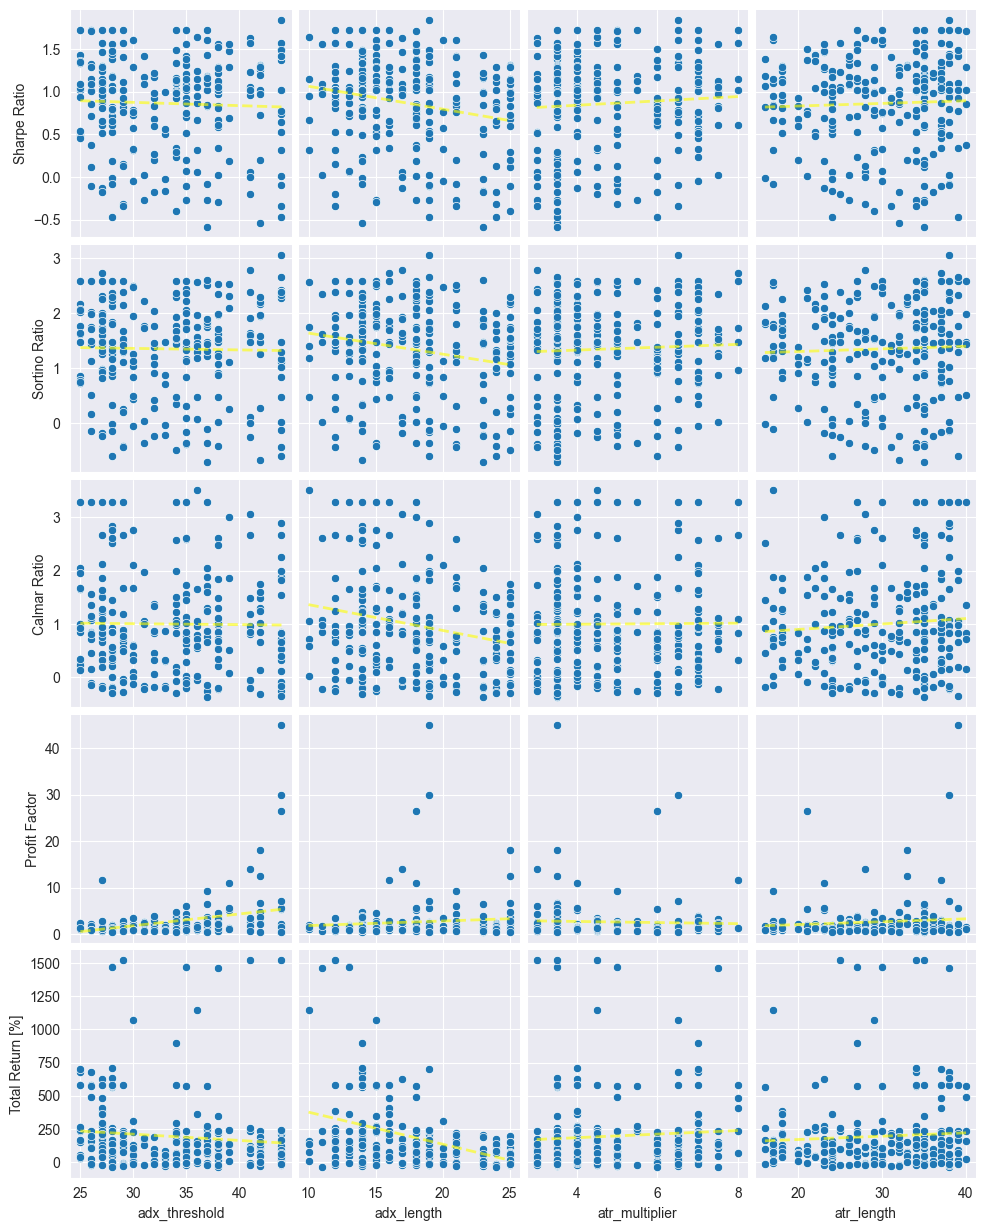

In [49]:
g5 = sns.pairplot(
    trials_summary3,
    x_vars=parameters,
    y_vars=performance,

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g5.axes[i, j]
        sns.regplot(
            data=trials_summary3,
            x=x,
            y=y,
            scatter=False,
            ci=None,
            ax=ax,

            line_kws={
                "linestyle": "--",  # dashed line
                "alpha": 0.6,  # transparency
                "lw": 2,  # line width
                "color": "yellow",
            },
        )


### Final Parameter Search Space

In [50]:
params_default = {'sar_acceleration': 0.02,  # little correlation
                  'sar_maximum': 0.2,  # has little correlation
                  'adx_threshold': [25, 45],  # higher adx_thresholds can result in no trades being executed
                  'adx_length': [14, 25],  # for entry
                  'atr_multiplier': [2, 6],  # for exit
                  'atr_length': [14, 25],  # atr multiplier for  exit
                  'use_high': False,
                  }




## Part 4: Extra, hmm but what does Optuna think is best?

I'll use the default search space and let Optuna explore the space and find the best parameters.

In [51]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 10, 46, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 10, 50, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 8, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, 50, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
params = params_default.copy()
study_opt = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_opt.optimize(objective, n_trials=n_trials)
trials_summary_opt = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-09 19:49:09,791] A new study created in memory with name: no-name-e0cda99e-3183-4194-8517-200f871222db
[I 2025-11-09 19:49:10,636] Trial 0 finished with value: 0.6575905507882781 and parameters: {'adx_threshold': 24, 'adx_length': 48, 'atr_multiplier': 6.0, 'atr_length': 34}. Best is trial 0 with value: 0.6575905507882781.
[I 2025-11-09 19:49:11,268] Trial 1 finished with value: 1.0705851134059727 and parameters: {'adx_threshold': 14, 'adx_length': 16, 'atr_multiplier': 1.0, 'atr_length': 46}. Best is trial 1 with value: 1.0705851134059727.
[I 2025-11-09 19:49:12,346] Trial 2 finished with value: 0.4790289307696634 and parameters: {'adx_threshold': 32, 'adx_length': 38, 'atr_multiplier': 1.0, 'atr_length': 50}. Best is trial 1 with value: 1.0705851134059727.
[I 2025-11-09 19:49:13,113] Trial 3 finished with value: 0.6672767496152318 and parameters: {'adx_threshold': 40, 'adx_length': 18, 'atr_multiplier': 2.0, 'atr_length': 16}. Best is trial 1 with value: 1.0705851134059727

In [52]:
trials = study_opt.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |      value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |
|----------|------------|--------------|-----------------|--------------|------------------|
|       12 |   1.18756  |           24 |              46 |           10 |              8   |
|       11 |   1.13981  |           24 |              44 |           10 |              8   |
|       10 |   1.13981  |           24 |              44 |           10 |              8   |
|       31 |   1.12172  |           22 |              42 |           10 |              8   |
|       21 |   1.12172  |           22 |              42 |           10 |              8   |
|       41 |   1.12172  |           22 |              42 |           10 |              8   |
|       42 |   1.11613  |           24 |              42 |           12 |              8   |
|       22 |   1.10234  |           24 |              44 |           12 |              7.5 |
|        9 |   1.07851  |           14 |              20 |           2

In [53]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

print(f"\nTop 10% Trials Summary:")
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary_opt.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Top 10% Trials Summary:

Per symbol:
       sar_acceleration                                          sar_maximum  \
                  count  mean  std   min   25%   50%   75%   max       count   
symbol                                                                         
BTC                 5.0  0.02  0.0  0.02  0.02  0.02  0.02  0.02         5.0   
ETH                 5.0  0.02  0.0  0.02  0.02  0.02  0.02  0.02         5.0   
SOL                 5.0  0.02  0.0  0.02  0.02  0.02  0.02  0.02         5.0   
TRX                 5.0  0.02  0.0  0.02  0.02  0.02  0.02  0.02         5.0   
XRP                 5.0  0.02  0.0  0.02  0.02  0.02  0.02  0.02         5.0   

             ... Profit Factor            Total Return [%]              \
       mean  ...           75%        max            count        mean   
symbol       ...                                                         
BTC     0.2  ...      6.191618   6.191618              5.0  313.542005   
ETH     0.2  ...      9.0

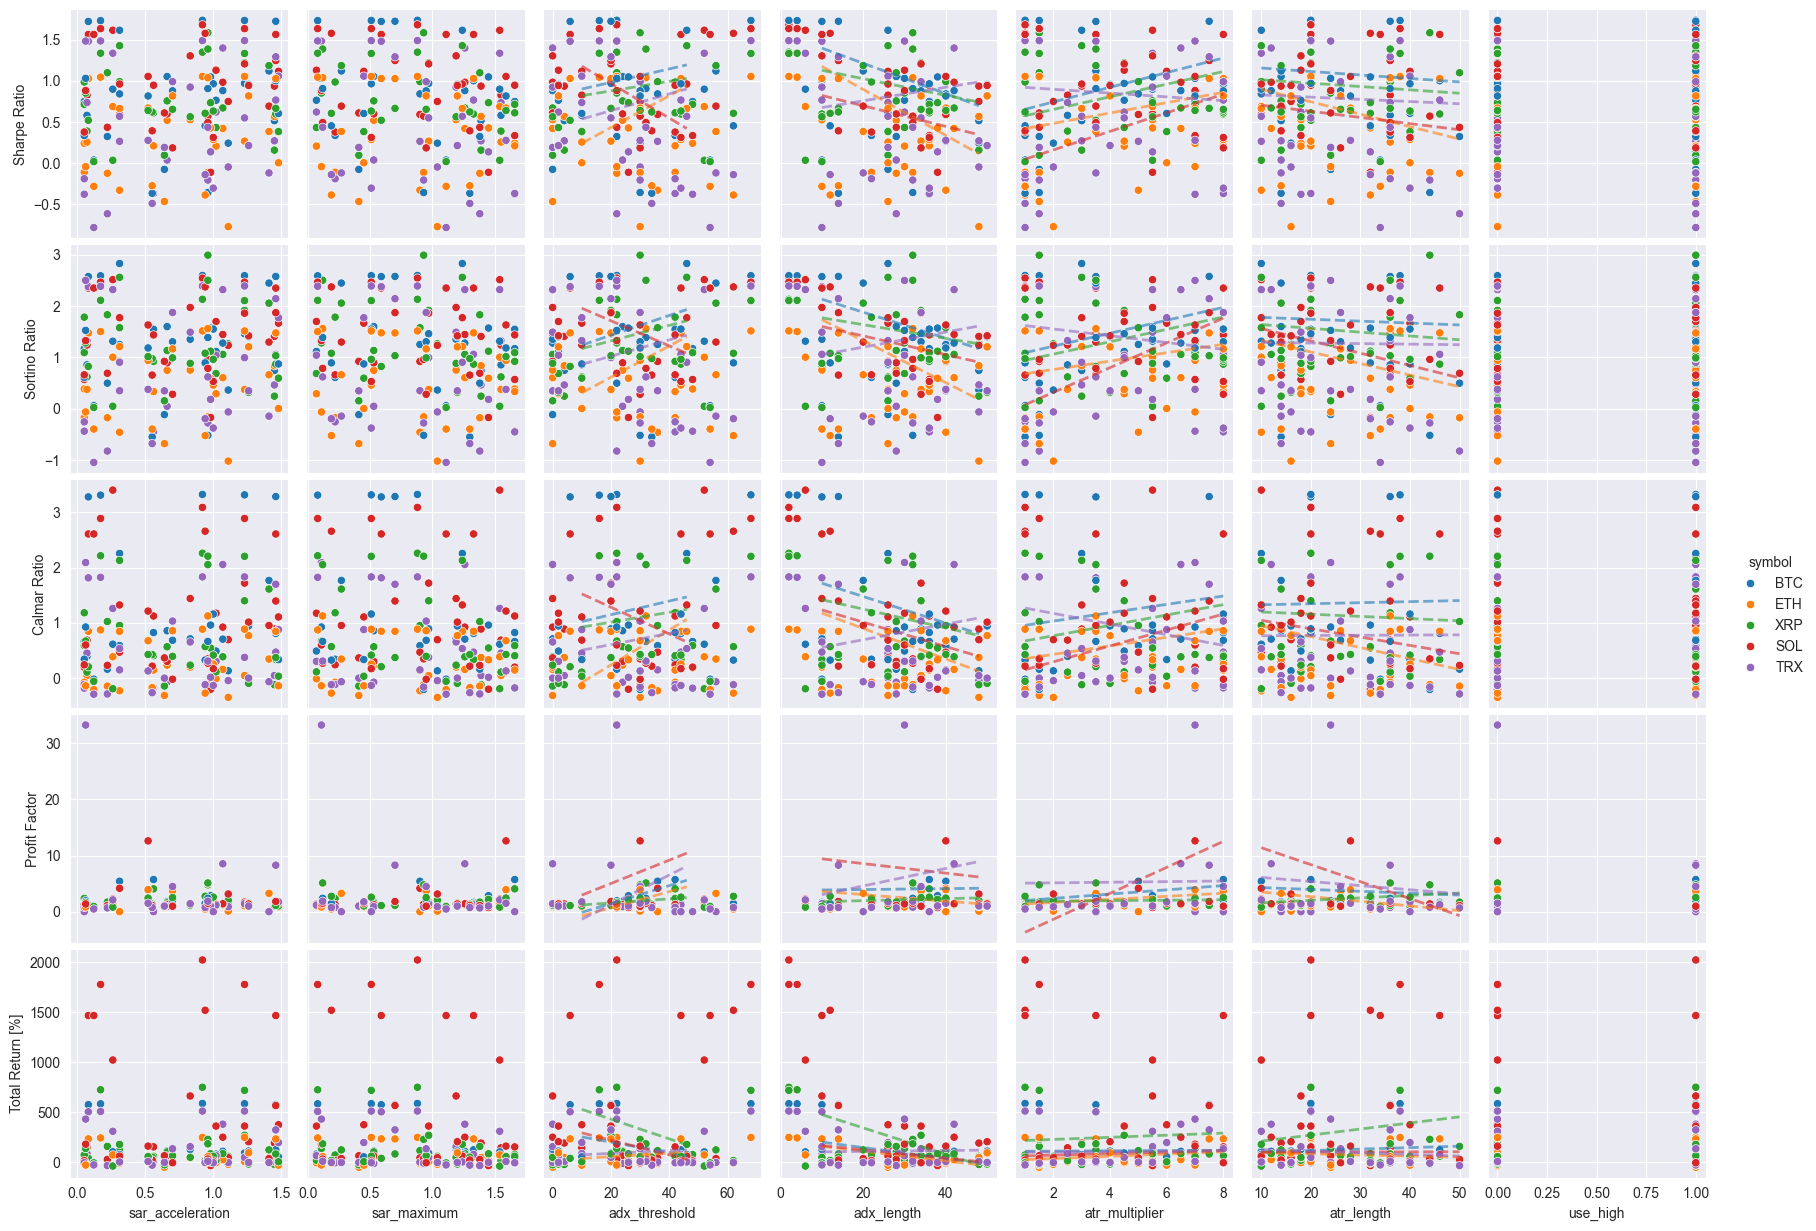

In [54]:
fig_opt = optuna.visualization.plot_param_importances(study_opt)
show(fig_opt)
fig_opt1 = optuna.visualization.plot_optimization_history(study_opt)
show(fig_opt1)
fig_opt2 = optuna.visualization.plot_slice(study_opt)
show(fig_opt2)

g_opt = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g_opt.axes[i, j]
        for sym, subdf in trials_summary_opt.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )


